In [105]:
import pandas as pd
import numpy as np

vendas_chocolate_df = pd.read_csv("Vendas_Chocolate.csv",sep=";")
display(vendas_chocolate_df)

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas,Data de Hoje
0,João Rocha,Reino Unido,Chocolate com Menta e Flocos,04/01/2022,"$5,320.00",180.0,03/02/2026
1,Vanderlei Teixeira,Índia,NaN,01/08/2022,"$7,896.00",94.0,NaN
2,Gisele Barbosa,Índia,Cubos de Manteiga de Amendoim,07/07/2022,"$4,501.00",91.0,NaN
3,Janaína Moreira,Austrália,Cubos de Manteiga de Amendoim,27/04/2022,"$12,726.00",342.0,NaN
4,João Rocha,Reino Unido,Cubos de Manteiga de Amendoim,24/02/2022,"$13,685.00",184.0,NaN
...,...,...,...,...,...,...,...
3277,Karina Machado,Austrália,Especiais Apimentados Finos,17/05/2024,"$5,303.58",354.0,NaN
3278,João Rocha,EUA,Chocolate Branco,07/06/2024,"$7,339.32",121.0,NaN
3279,Célio Bonfim,Canadá,Xarope de Chocolate Orgânico,26/07/2024,$616.09,238.0,NaN
3280,Doroti Santos,Índia,Bombas de Chocolate,28/07/2024,"$2,504.62",397.0,NaN


In [106]:
# Analisando a estrutura do dataframe
display(vendas_chocolate_df.info())
display(vendas_chocolate_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Vendedor         3250 non-null   str    
 1   País             3250 non-null   str    
 2   Produto          3250 non-null   str    
 3   Data             3282 non-null   str    
 4   Valor            3282 non-null   str    
 5   Caixas Enviadas  3250 non-null   float64
 6   Data de Hoje     1 non-null      str    
dtypes: float64(1), str(6)
memory usage: 179.6 KB


None

,Caixas Enviadas
count,3250.000000
mean,164.220923
std,123.740233
min,1.000000
25%,71.000000
50%,136.500000
75%,232.000000
max,778.000000


In [107]:
# Tirando colunas inúteis
analise_vendas_chocolate_df = vendas_chocolate_df.drop(columns="Data de Hoje")
display(vendas_chocolate_df.head())

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas,Data de Hoje
0,João Rocha,Reino Unido,Chocolate com Menta e Flocos,04/01/2022,"$5,320.00",180.0,03/02/2026
1,Vanderlei Teixeira,Índia,NaN,01/08/2022,"$7,896.00",94.0,NaN
2,Gisele Barbosa,Índia,Cubos de Manteiga de Amendoim,07/07/2022,"$4,501.00",91.0,NaN
3,Janaína Moreira,Austrália,Cubos de Manteiga de Amendoim,27/04/2022,"$12,726.00",342.0,NaN
4,João Rocha,Reino Unido,Cubos de Manteiga de Amendoim,24/02/2022,"$13,685.00",184.0,NaN


In [108]:
# Ajustando os tipos de dados
analise_vendas_chocolate_df["Data"] = pd.to_datetime(analise_vendas_chocolate_df["Data"], format="%d/%m/%Y")
analise_vendas_chocolate_df["Valor"] = analise_vendas_chocolate_df["Valor"].str.replace("$","").str.replace(",","")
analise_vendas_chocolate_df["Valor"] = analise_vendas_chocolate_df["Valor"].astype(float)
display(analise_vendas_chocolate_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Vendedor         3250 non-null   str           
 1   País             3250 non-null   str           
 2   Produto          3250 non-null   str           
 3   Data             3282 non-null   datetime64[us]
 4   Valor            3282 non-null   float64       
 5   Caixas Enviadas  3250 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 154.0 KB


None

In [109]:
# Ajustando colunas com linhas vazias
analise_vendas_chocolate_df = analise_vendas_chocolate_df.dropna(subset=["Vendedor", "País", "Produto", "Data", "Valor", "Caixas Enviadas"])
# Ajustando duplicatas
analise_vendas_chocolate_df = analise_vendas_chocolate_df.drop_duplicates()
analise_vendas_chocolate_df = analise_vendas_chocolate_df.reset_index(drop=True)

display(analise_vendas_chocolate_df)
display(analise_vendas_chocolate_df.info())
display(analise_vendas_chocolate_df.describe())

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas
0,João Rocha,Reino Unido,Chocolate com Menta e Flocos,2022-01-04,5320.00,180.0
1,Gisele Barbosa,Índia,Cubos de Manteiga de Amendoim,2022-07-07,4501.00,91.0
2,Janaína Moreira,Austrália,Cubos de Manteiga de Amendoim,2022-04-27,12726.00,342.0
3,João Rocha,Reino Unido,Cubos de Manteiga de Amendoim,2022-02-24,13685.00,184.0
4,Vanderlei Teixeira,Índia,Salgadinho Suave e Sedoso,2022-06-06,5376.00,38.0
...,...,...,...,...,...,...
3150,Karina Machado,Austrália,Especiais Apimentados Finos,2024-05-17,5303.58,354.0
3151,João Rocha,EUA,Chocolate Branco,2024-06-07,7339.32,121.0
3152,Célio Bonfim,Canadá,Xarope de Chocolate Orgânico,2024-07-26,616.09,238.0
3153,Doroti Santos,Índia,Bombas de Chocolate,2024-07-28,2504.62,397.0


<class 'pandas.DataFrame'>
RangeIndex: 3155 entries, 0 to 3154
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Vendedor         3155 non-null   str           
 1   País             3155 non-null   str           
 2   Produto          3155 non-null   str           
 3   Data             3155 non-null   datetime64[us]
 4   Valor            3155 non-null   float64       
 5   Caixas Enviadas  3155 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 148.0 KB


None

,Data,Valor,Caixas Enviadas
count,3155,3155.000000,3155.000000
mean,2023-05-01 17:10:08.177496,6021.792041,164.105547
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-06-30 00:00:00,2510.805000,71.000000
50%,2023-05-10 00:00:00,5220.800000,137.000000
75%,2024-03-01 12:00:00,8548.920000,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.267909,123.288244


In [110]:
# Análise temporal de vendas

analise_vendas_chocolate_df["Mes/ano"] = analise_vendas_chocolate_df["Data"].dt.to_period("M")
analise_vendas_chocolate_df["Ano"] = analise_vendas_chocolate_df["Data"].dt.year
display(analise_vendas_chocolate_df)

,Vendedor,País,Produto,Data,Valor,Caixas Enviadas,Mes/ano,Ano
0,João Rocha,Reino Unido,Chocolate com Menta e Flocos,2022-01-04,5320.00,180.0,2022-01,2022
1,Gisele Barbosa,Índia,Cubos de Manteiga de Amendoim,2022-07-07,4501.00,91.0,2022-07,2022
2,Janaína Moreira,Austrália,Cubos de Manteiga de Amendoim,2022-04-27,12726.00,342.0,2022-04,2022
3,João Rocha,Reino Unido,Cubos de Manteiga de Amendoim,2022-02-24,13685.00,184.0,2022-02,2022
4,Vanderlei Teixeira,Índia,Salgadinho Suave e Sedoso,2022-06-06,5376.00,38.0,2022-06,2022
...,...,...,...,...,...,...,...,...
3150,Karina Machado,Austrália,Especiais Apimentados Finos,2024-05-17,5303.58,354.0,2024-05,2024
3151,João Rocha,EUA,Chocolate Branco,2024-06-07,7339.32,121.0,2024-06,2024
3152,Célio Bonfim,Canadá,Xarope de Chocolate Orgânico,2024-07-26,616.09,238.0,2024-07,2024
3153,Doroti Santos,Índia,Bombas de Chocolate,2024-07-28,2504.62,397.0,2024-07,2024


,Mes/ano,Valor
0,2022-01,860363.00
1,2022-02,699377.00
2,2022-03,726418.00
3,2022-04,653198.00
4,2022-05,740103.00
5,2022-06,836465.00
6,2022-07,772177.00
7,2022-08,709065.00
8,2023-01,900155.00
9,2023-02,729416.95


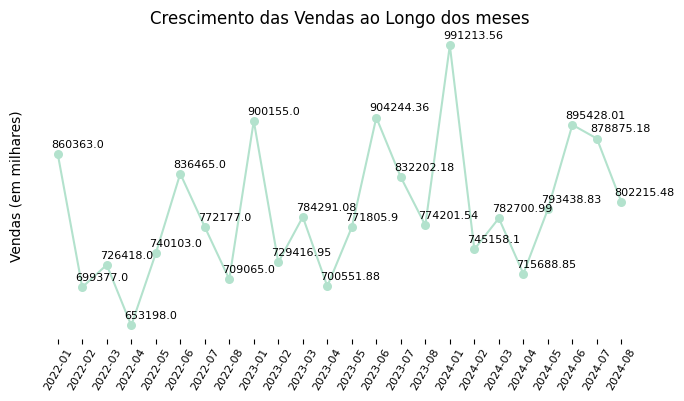

In [111]:
# Análise de Vendas por mês
vendas_por_mes_df = analise_vendas_chocolate_df[["Mes/ano","Valor"]].groupby("Mes/ano",as_index=False).sum()
display(vendas_por_mes_df)

# Gráfico
import matplotlib.pyplot as plt
from cycler import cycler

cores = plt.get_cmap('Pastel2').colors
ciclo_cores = cycler('color', cores)
plt.rc('axes', prop_cycle=ciclo_cores)

plt.figure(figsize=(8, 4))
plt.plot(vendas_por_mes_df["Mes/ano"].astype(str), vendas_por_mes_df["Valor"])

plt.ylabel('Vendas (em milhares)')
plt.title('Crescimento das Vendas ao Longo dos meses')

plt.yticks([])
plt.xticks(fontsize = 8, rotation = 60)
plt.tick_params(axis="x",pad = 1)

for posicao in range(len(vendas_por_mes_df["Valor"])):
    plt.scatter(vendas_por_mes_df["Mes/ano"].astype(str)[posicao], vendas_por_mes_df["Valor"][posicao], s=30, color=cores[0])
    plt.annotate(vendas_por_mes_df["Valor"][posicao], xy=(vendas_por_mes_df["Mes/ano"].astype(str)[posicao], vendas_por_mes_df["Valor"][posicao]), xytext=(-5, 5), textcoords='offset points', fontsize = 8)

plt.box(False)

plt.show()


In [112]:
# Análise de volume e ticket médio anual

vendas_por_ano_df = analise_vendas_chocolate_df[["Ano","Valor", "Caixas Enviadas"]].groupby("Ano",as_index=False).sum()

vendas_por_ano_df["Ticket médio"] = vendas_por_ano_df["Valor"] / vendas_por_ano_df["Caixas Enviadas"]

vendas_por_ano_df["% Crescimento valor"] = vendas_por_ano_df["Valor"].pct_change()

display(vendas_por_ano_df.style.format({
    "Valor": "${:,.2f}",
    "Caixas Enviadas": "{:,.2f}",
    "Ticket médio": "${:,.2f}",
    "% Crescimento valor": "{:.2%}"
}))

,Ano,Valor,Caixas Enviadas,Ticket médio,% Crescimento valor
0,2022,"$5,997,166.00","171,422.00",$34.98,nan%
1,2023,"$6,396,868.89","173,970.00",$36.77,6.66%
2,2024,"$6,604,719.00","172,361.00",$38.32,3.25%


In [113]:
# Análise produto anual
produtos_anul_df = analise_vendas_chocolate_df[["Ano", "Produto", "Valor"]]
produtos_anul_df = produtos_anul_df.groupby(["Ano","Produto"], as_index=False).sum()

display(produtos_anul_df)

# Gráfico 
import plotly.express as px

grafico = px.bar(produtos_anul_df, x = "Ano", y="Valor", color = "Produto")
grafico.show()

,Ano,Produto,Valor
0,2022,99% Amargo e Puro,270144.00
1,2022,Amêndoas Cobertas com Chocolate,238847.00
2,2022,Barras 85% Cacau,283297.00
3,2022,Barras Recheadas com Caramelo,231588.00
4,2022,Barras de Chocolate ao Leite,258867.00
...,...,...,...
61,2024,Gotas de Chocolate de Confeiteiro,281787.05
62,2024,Mordidas 50% Cacau,355627.08
63,2024,Mordidas 70% Cacau,237490.12
64,2024,Salgadinho Suave e Sedoso,370077.04
